In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms

from PIL import Image
import rasterio

from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

print("CUDA available:", torch.cuda.is_available())
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

CUDA available: True
Using device: cuda


In [3]:
RGB_TRAIN = "EuroSAT/train"
RGB_VAL   = "EuroSAT/val"
MS_TRAIN  = "EuroSATallBands/train"
MS_VAL    = "EuroSATallBands/val"
RGB_TEST  = "EuroSAT_test_flat"
MS_TEST   = "EuroSATallBands_test_flat"

CLASSES = [
    "AnnualCrop", "Forest", "HerbaceousVegetation", "Highway",
    "Industrial", "Pasture", "PermanentCrop", "Residential",
    "River", "SeaLake"
]
CLASS_TO_IDX = {c: i for i, c in enumerate(CLASSES)}
NUM_CLASSES  = 10

BATCH_SIZE = 32
EPOCHS     = 50
LR         = 3e-4
PATIENCE   = 7

In [4]:
rgb_train_transforms = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

rgb_val_transforms = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

class RGBDataset(Dataset):
    def __init__(self, root, transform=None):
        self.samples = []
        self.transform = transform
        for cls in CLASSES:
            folder = os.path.join(root, cls)
            for fname in os.listdir(folder):
                if fname.lower().endswith(".jpg"):
                    self.samples.append((os.path.join(folder, fname), CLASS_TO_IDX[cls]))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, label

rgb_train_ds = RGBDataset(RGB_TRAIN, rgb_train_transforms)
rgb_val_ds   = RGBDataset(RGB_VAL,   rgb_val_transforms)
print("RGB train:", len(rgb_train_ds), "| val:", len(rgb_val_ds))

RGB train: 18900 | val: 4050


In [5]:
class MSDataset(Dataset):
    def __init__(self, root, augment=False):
        self.samples = []
        self.augment = augment
        for cls in CLASSES:
            folder = os.path.join(root, cls)
            for fname in os.listdir(folder):
                if fname.lower().endswith(".tif"):
                    self.samples.append((os.path.join(folder, fname), CLASS_TO_IDX[cls]))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        with rasterio.open(path) as src:
            img = src.read().astype(np.float32)  # (13, 64, 64)
        img = np.clip(img / 10000.0, 0, 1)
        img = torch.tensor(img)

        if self.augment:
            if torch.rand(1) > 0.5:
                img = torch.flip(img, dims=[2])  # horizontal flip
            if torch.rand(1) > 0.5:
                img = torch.flip(img, dims=[1])  # vertical flip
            k = torch.randint(0, 4, (1,)).item()
            img = torch.rot90(img, k, dims=[1, 2])  # random 90-degree rotation

        return img, label

ms_train_ds = MSDataset(MS_TRAIN, augment=True)
ms_val_ds   = MSDataset(MS_VAL,   augment=False)
print("MS train:", len(ms_train_ds), "| val:", len(ms_val_ds))
img, lbl = ms_train_ds[0]
print("MS shape:", img.shape, "| min:", img.min().item(), "| max:", img.max().item())

MS train: 18900 | val: 4050
MS shape: torch.Size([13, 64, 64]) | min: 0.0008999999845400453 | max: 0.3490000069141388


In [6]:
rgb_train_loader = DataLoader(rgb_train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=True)
rgb_val_loader   = DataLoader(rgb_val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
ms_train_loader  = DataLoader(ms_train_ds,  batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=True)
ms_val_loader    = DataLoader(ms_val_ds,    batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

In [7]:
class SpectralAttention(nn.Module):
    def __init__(self, num_bands, reduction=4):
        super().__init__()
        # squeeze: global avg pool collapses spatial dims, leaving one value per band
        # excitation: two linear layers learn which bands matter
        self.excitation = nn.Sequential(
            nn.Linear(num_bands, num_bands // reduction),
            nn.ReLU(),
            nn.Linear(num_bands // reduction, num_bands),
            nn.Sigmoid()  # outputs weights between 0 and 1 per band
        )

    def forward(self, x):
        # x shape: (batch, bands, H, W)
        weights = x.mean(dim=[2, 3])          # global avg pool: (batch, bands)
        weights = self.excitation(weights)     # (batch, bands)
        weights = weights.unsqueeze(-1).unsqueeze(-1)  # (batch, bands, 1, 1)
        return x * weights, weights.squeeze() # rescaled input + weights for inspection

In [8]:
class AttentionCNN(nn.Module):
    def __init__(self, in_channels, num_classes=10):
        super().__init__()
        self.attention = SpectralAttention(in_channels)
        self.features  = nn.Sequential(
            nn.Conv2d(in_channels, 32, 3, padding=1),  nn.BatchNorm2d(32),  nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1),           nn.BatchNorm2d(64),  nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1),          nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(128, 256, 3, padding=1),         nn.BatchNorm2d(256), nn.ReLU(), nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 4 * 4, 512), nn.ReLU(), nn.Dropout(0.4),
            nn.Linear(512, num_classes)
        )

    def forward(self, x, return_weights=False):
        x, weights = self.attention(x)
        out = self.classifier(self.features(x))
        if return_weights:
            return out, weights
        return out

# sanity check
m = AttentionCNN(in_channels=13).to(device)
dummy = torch.randn(2, 13, 64, 64).to(device)
out, w = m(dummy, return_weights=True)
print("Output shape:", out.shape)
print("Attention weights shape:", w.shape)  # (batch, 13)

Output shape: torch.Size([2, 10])
Attention weights shape: torch.Size([2, 13])


In [9]:
class EarlyStopping:
    def __init__(self, patience=7, save_path="best_model.pt"):
        self.patience  = patience
        self.best_loss = float("inf")
        self.counter   = 0
        self.save_path = save_path

    def step(self, val_loss, model):
        if val_loss < self.best_loss:
            self.best_loss = val_loss
            self.counter   = 0
            torch.save(model.state_dict(), self.save_path)
            return False
        self.counter += 1
        return self.counter >= self.patience


def train_one_epoch(model, loader, optimizer, criterion, grad_clip=None):
    model.train()
    total_loss, correct = 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        out  = model(x)
        loss = criterion(out, y)
        loss.backward()
        if grad_clip:
            nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
        optimizer.step()
        total_loss += loss.item() * x.size(0)
        correct    += (out.argmax(1) == y).sum().item()
    n = len(loader.dataset)
    return total_loss / n, correct / n


def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct = 0, 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            out  = model(x)
            loss = criterion(out, y)
            total_loss += loss.item() * x.size(0)
            correct    += (out.argmax(1) == y).sum().item()
    n = len(loader.dataset)
    return total_loss / n, correct / n


def run_training(model, train_loader, val_loader, save_path,
                 epochs=EPOCHS, lr=LR, patience=PATIENCE, grad_clip=None):
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, factor=0.5)
    criterion = nn.CrossEntropyLoss()
    stopper   = EarlyStopping(patience=patience, save_path=save_path)
    history   = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    for epoch in range(1, epochs + 1):
        tl, ta = train_one_epoch(model, train_loader, optimizer, criterion, grad_clip)
        vl, va = evaluate(model, val_loader, criterion)
        scheduler.step(vl)
        history["train_loss"].append(tl)
        history["val_loss"].append(vl)
        history["train_acc"].append(ta)
        history["val_acc"].append(va)
        print(f"Epoch {epoch:02d} | train_loss={tl:.4f} acc={ta:.3f} | val_loss={vl:.4f} acc={va:.3f}")
        if stopper.step(vl, model):
            print(f"Early stopping at epoch {epoch}. Best val_loss={stopper.best_loss:.4f}")
            break

    model.load_state_dict(torch.load(save_path))
    return history

In [ ]:
def plot_history(history, title):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    ax1.plot(history["train_loss"], label="train")
    ax1.plot(history["val_loss"],   label="val")
    ax1.set_title(f"{title} - Loss"); ax1.legend()
    ax2.plot(history["train_acc"], label="train")
    ax2.plot(history["val_acc"],   label="val")
    ax2.set_title(f"{title} - Accuracy"); ax2.legend()
    plt.tight_layout(); plt.show()

In [10]:
attn_rgb = AttentionCNN(in_channels=3).to(device)
history_attn_rgb = run_training(
    attn_rgb, rgb_train_loader, rgb_val_loader,
    save_path="attn_rgb_best.pt",
    grad_clip=1.0
)

c:\Users\KAUSTUBH\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\nn\modules\linear.py:124: UserWarning: Initializing zero-element tensors is a no-op
  init.kaiming_uniform_(self.weight, a=math.sqrt(5))


Epoch 01 | train_loss=0.9469 acc=0.661 | val_loss=0.6744 acc=0.750
Epoch 02 | train_loss=0.7112 acc=0.749 | val_loss=0.4968 acc=0.829
Epoch 03 | train_loss=0.6094 acc=0.786 | val_loss=0.5375 acc=0.800
Epoch 04 | train_loss=0.5430 acc=0.811 | val_loss=0.5062 acc=0.825
Epoch 05 | train_loss=0.5083 acc=0.825 | val_loss=0.3790 acc=0.865
Epoch 06 | train_loss=0.4646 acc=0.838 | val_loss=0.3172 acc=0.893
Epoch 07 | train_loss=0.4401 acc=0.846 | val_loss=0.3361 acc=0.881
Epoch 08 | train_loss=0.4089 acc=0.858 | val_loss=0.3010 acc=0.897
Epoch 09 | train_loss=0.3894 acc=0.863 | val_loss=0.3236 acc=0.891
Epoch 10 | train_loss=0.3696 acc=0.869 | val_loss=0.3061 acc=0.889
Epoch 11 | train_loss=0.3613 acc=0.875 | val_loss=0.2714 acc=0.904
Epoch 12 | train_loss=0.3509 acc=0.879 | val_loss=0.3242 acc=0.888
Epoch 13 | train_loss=0.3353 acc=0.886 | val_loss=0.2607 acc=0.911
Epoch 14 | train_loss=0.3240 acc=0.887 | val_loss=0.2276 acc=0.918
Epoch 15 | train_loss=0.3165 acc=0.888 | val_loss=0.2143 acc=0

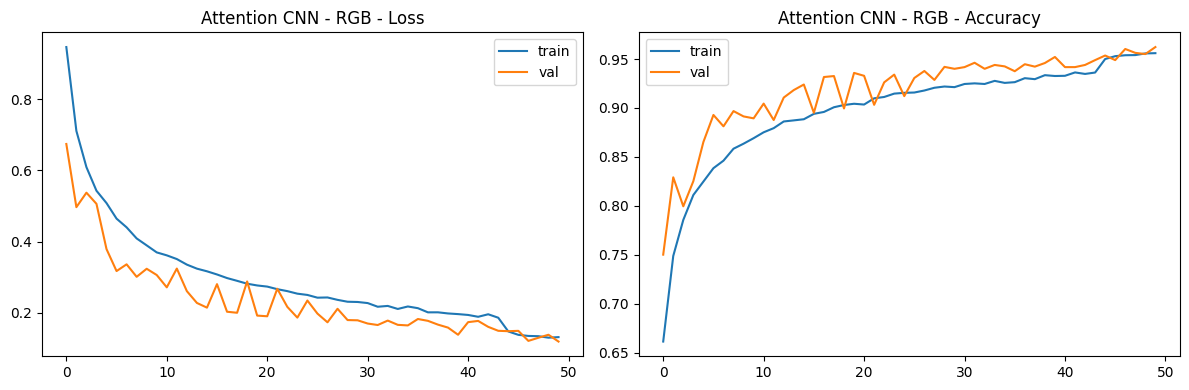

In [14]:
plot_history(history_attn_rgb, "Attention CNN - RGB")

In [17]:
attn_ms = AttentionCNN(in_channels=13).to(device)
history_attn_ms = run_training(
    attn_ms, ms_train_loader, ms_val_loader,
    save_path="attn_ms_best.pt",
    patience=5,
    grad_clip=1.0
)

Epoch 01 | train_loss=0.5945 acc=0.799 | val_loss=1.0681 acc=0.714
Epoch 02 | train_loss=0.3719 acc=0.876 | val_loss=0.3499 acc=0.883
Epoch 03 | train_loss=0.2926 acc=0.904 | val_loss=0.7099 acc=0.785
Epoch 04 | train_loss=0.2668 acc=0.914 | val_loss=0.3698 acc=0.880
Epoch 05 | train_loss=0.2377 acc=0.926 | val_loss=0.3546 acc=0.891
Epoch 06 | train_loss=0.2248 acc=0.928 | val_loss=0.2831 acc=0.902
Epoch 07 | train_loss=0.2020 acc=0.936 | val_loss=0.3274 acc=0.898
Epoch 08 | train_loss=0.1917 acc=0.940 | val_loss=0.3115 acc=0.904
Epoch 09 | train_loss=0.1867 acc=0.940 | val_loss=0.3814 acc=0.870
Epoch 10 | train_loss=0.1732 acc=0.945 | val_loss=1.2225 acc=0.737
Epoch 11 | train_loss=0.1263 acc=0.960 | val_loss=0.1042 acc=0.965
Epoch 12 | train_loss=0.1098 acc=0.964 | val_loss=0.1597 acc=0.951
Epoch 13 | train_loss=0.1079 acc=0.966 | val_loss=0.2581 acc=0.924
Epoch 14 | train_loss=0.1115 acc=0.965 | val_loss=0.1175 acc=0.965
Epoch 15 | train_loss=0.1039 acc=0.968 | val_loss=0.0993 acc=0

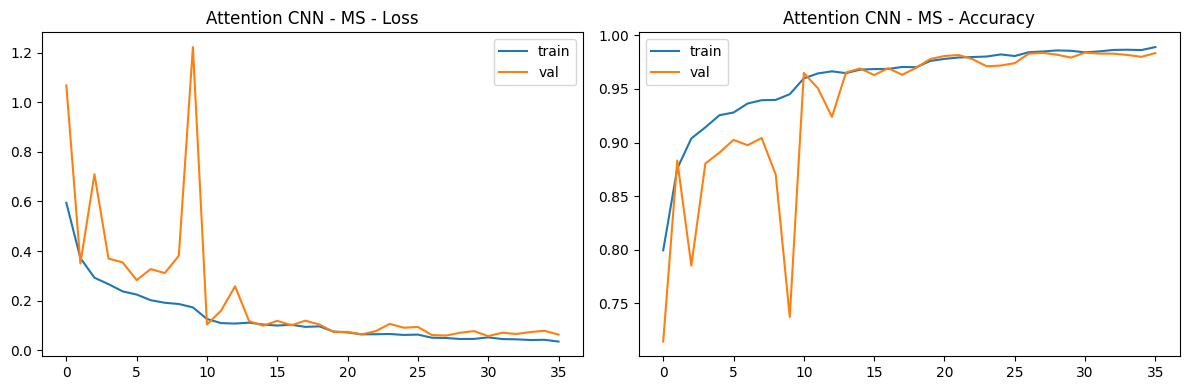

In [18]:
plot_history(history_attn_ms,  "Attention CNN - MS")